In [1]:
pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'adult.data', 'adult.zip', 'Dataintegartion2.ipynb', 'DataIntegration.ipynb', 'gender_submission.csv.csv', 'gender_submission_cleaned.csv', 'Handout2', 'irisdata.csv', 'train.csv', 'Untitled.ipynb', 'untitled.py', 'untitled1.py']


   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

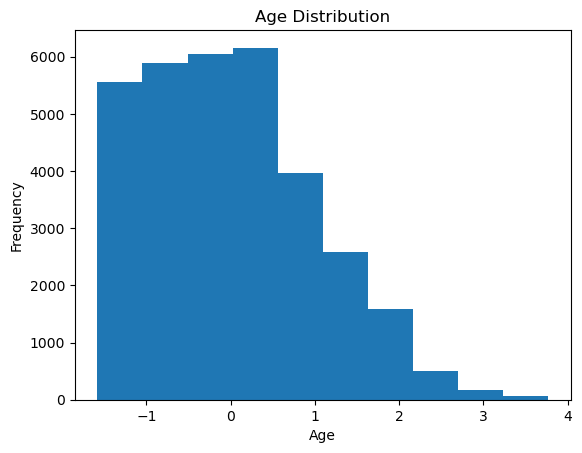

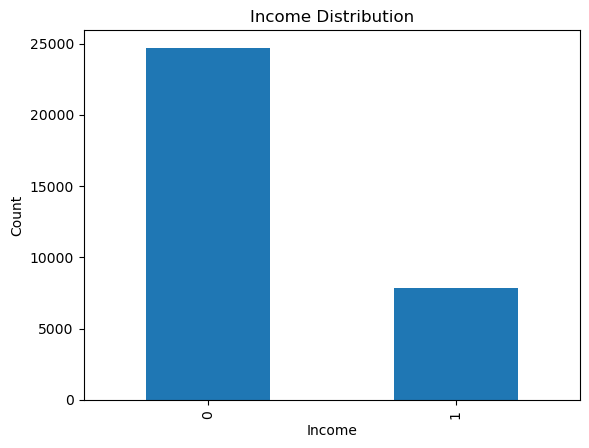

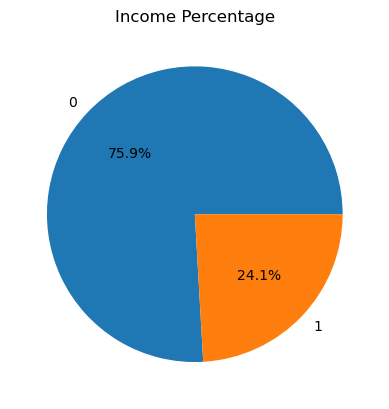

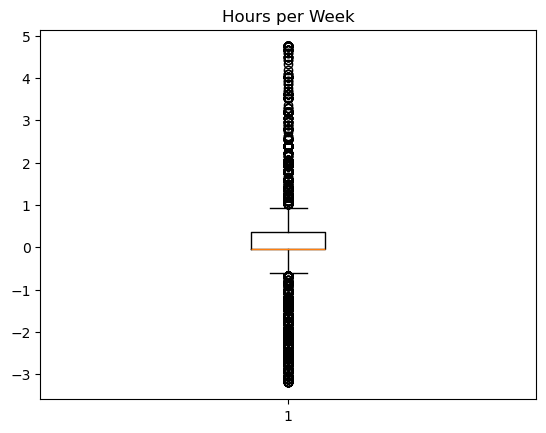

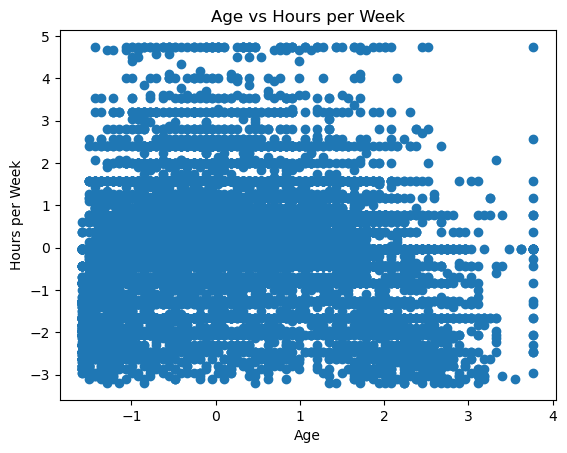

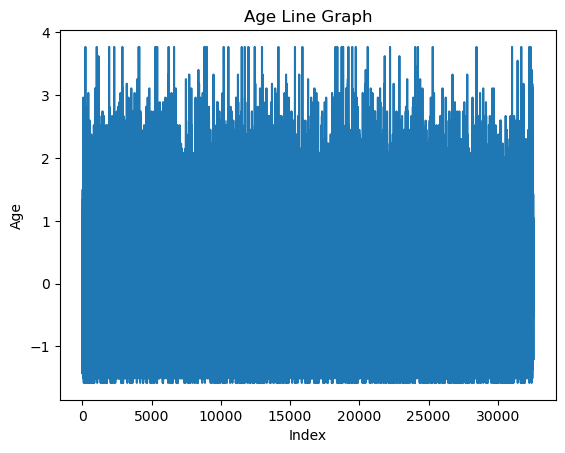

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Column names
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race",
    "sex", "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

# Read the dataset
df = pd.read_csv(
    "adult.data",
    header=None,
    names=columns,
    skipinitialspace=True
)

# Display first 5 rows
print(df.head())

# Dataset information
print(df.info())

# Shape
print(df.shape)

# Column names
print(df.columns)

# Missing values
df.replace("?", np.nan, inplace=True)

print(df.isnull().sum())

# Fill missing values
df["workclass"] = df["workclass"].fillna(df["workclass"].mode()[0])

df["occupation"] = df["occupation"].fillna(df["occupation"].mode()[0])

df["native-country"] = df["native-country"].fillna(df["native-country"].mode()[0])

# Duplicate rows
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Data types
print(df.dtypes)

# Label Encoding
le = LabelEncoder()

categorical_columns = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "income"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Feature Scaling
scaler = StandardScaler()

numerical_columns = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Statistical summary
print(df.describe())

# Outlier Detection
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) |
            (df > (Q3 + 1.5 * IQR)))

print(outliers.sum())

# Save cleaned dataset
df.to_csv("adult_cleaned.csv", index=False)

print("Data preprocessing completed successfully!")

# ---------------- Graphs ---------------- #

# Histogram
plt.hist(df["age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Bar Chart
df["income"].value_counts().plot(kind="bar")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

# Pie Chart
df["income"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Income Percentage")
plt.ylabel("")
plt.show()

# Box Plot
plt.boxplot(df["hours-per-week"])
plt.title("Hours per Week")
plt.show()

# Scatter Plot
plt.scatter(df["age"], df["hours-per-week"])
plt.title("Age vs Hours per Week")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()

# Line Plot
plt.plot(df["age"])
plt.title("Age Line Graph")
plt.xlabel("Index")
plt.ylabel("Age")
plt.show()